In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
 #load datasets
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

/tmp/ipykernel_1330/2805993339.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


In [6]:
# basic info
print("Sentiment Shape :", sentiment.shape)
print("Trades Shape :", trades.shape)

print(sentiment.head())
print(trades.head())


Sentiment Shape : (2644, 4)
Trades Shape : (181921, 16)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596      

In [7]:
# missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())


timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [8]:
# remove duplicates
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()



In [9]:
# convert dates
sentiment["date"] = pd.to_datetime(sentiment["date"])

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], errors="coerce")
trades["date"] = trades["Timestamp IST"].dt.date
trades["date"] = pd.to_datetime(trades["date"])


In [10]:
# convert numbers
trades["Closed PnL"] = pd.to_numeric(trades["Closed PnL"], errors="coerce")
trades["Size USD"] = pd.to_numeric(trades["Size USD"], errors="coerce")
trades["Fee"] = pd.to_numeric(trades["Fee"], errors="coerce")


In [11]:

# leverage if available
if "Leverage" in trades.columns:
    trades["Leverage"] = pd.to_numeric(trades["Leverage"], errors="coerce")

# merge datasets
data = pd.merge(trades, sentiment, on="date", how="left")

print(data.head())

# create win column
data["win"] = 0
data.loc[data["Closed PnL"] > 0, "win"] = 1


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451

In [12]:
# create side columns if available
if "Side" in data.columns:
    long_count = data[data["Side"] == "BUY"].shape[0]
    short_count = data[data["Side"] == "SELL"].shape[0]
    print("Long Trades :", long_count)
    print("Short Trades :", short_count)



Long Trades : 88407
Short Trades : 93514


In [14]:
# daily trader metrics
daily = data.groupby(["date", "Account", "classification"]).agg(
    daily_pnl=("Closed PnL", "sum"),
    win_rate=("win", "mean"),
    avg_trade_size=("Size USD", "mean"),
    trades=("Account", "count")
).reset_index()

print(daily.head())

        date                                     Account classification  \
0 2023-01-05  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891           Fear   
1 2023-05-12  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23        Neutral   
2 2024-01-01  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
3 2024-01-02  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
4 2024-01-03  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4          Greed   

     daily_pnl  win_rate  avg_trade_size  trades  
0     0.000000  0.000000      159.000000       3  
1     0.000000  0.000000     5556.203333       9  
2  -129.531460  0.055556    14679.973889      18  
3     0.000000  0.000000      334.696667       6  
4  8244.241409  0.934307     3452.370073     137  


In [15]:
# fear greed performance
summary = daily.groupby("classification").agg({
    "daily_pnl":"mean",
    "win_rate":"mean",
    "avg_trade_size":"mean",
    "trades":"mean"
})

print(summary)


                   daily_pnl  win_rate  avg_trade_size     trades
classification                                                   
Extreme Fear      470.031091  0.197428     7755.088611  66.620690
Extreme Greed   10517.215233  0.342053     7103.067572  50.936364
Fear            11044.797661  0.361444     7012.140566  87.232877
Greed            3920.964418  0.345798     6777.478113  58.291209
Neutral          2073.798388  0.321205     5845.984726  75.111111


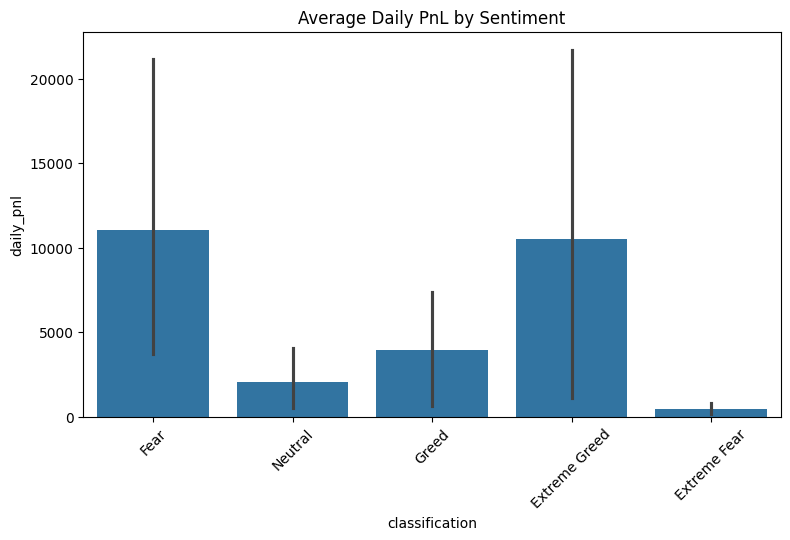

In [16]:
# chart 1 pnl
plt.figure(figsize=(9,5))
sns.barplot(x="classification", y="daily_pnl", data=daily)
plt.xticks(rotation=45)
plt.title("Average Daily PnL by Sentiment")
plt.show()


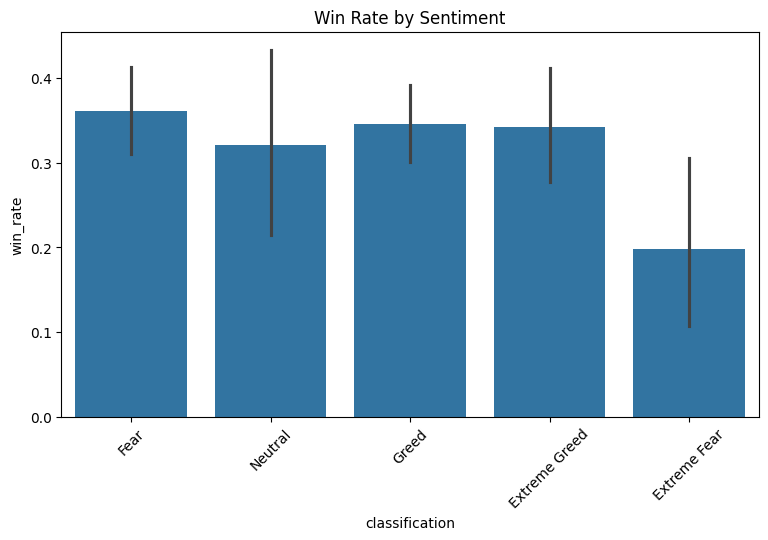

In [17]:
# chart 2 win rate
plt.figure(figsize=(9,5))
sns.barplot(x="classification", y="win_rate", data=daily)
plt.xticks(rotation=45)
plt.title("Win Rate by Sentiment")
plt.show()


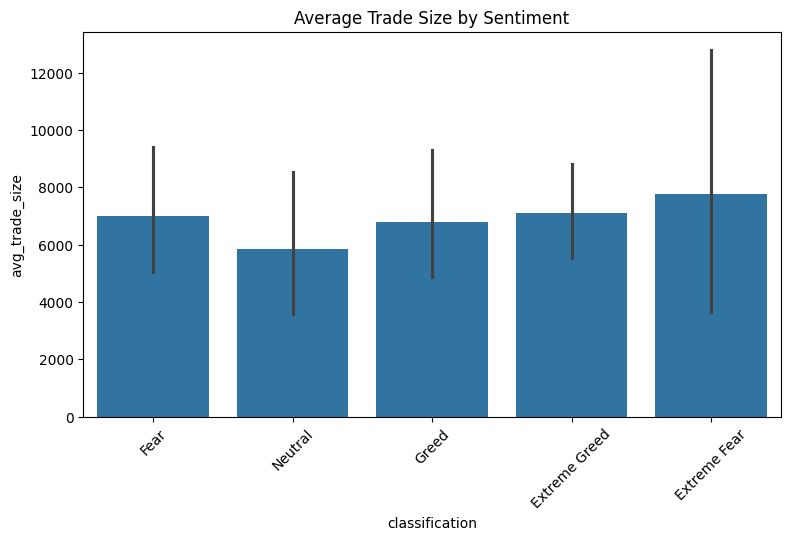

In [18]:
# chart 3 trade size
plt.figure(figsize=(9,5))
sns.barplot(x="classification", y="avg_trade_size", data=daily)
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()




In [28]:
# trader level summary
trader = data.groupby("Account").agg(
    total_pnl=("Closed PnL", "sum"),
    trades=("Account", "count"),
    avg_size=("Size USD", "mean")
).reset_index()

mid_trade = trader["trades"].median()
trader["frequency"] = "Infrequent"
trader.loc[trader["trades"] >= mid_trade, "frequency"] = "Frequent"

In [29]:
# segment 1 frequent vs infrequent


In [30]:

# segment 2 winner vs loser
trader["result"] = "Loser"
trader.loc[trader["total_pnl"] > 0, "result"] = "Winner"


In [31]:
# segment 3 large vs small
mid_size = trader["avg_size"].median()

trader["size_type"] = "Small"
trader.loc[trader["avg_size"] >= mid_size, "size_type"] = "Large"

print(trader.head())


                                      Account     total_pnl  trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06    3818   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04    7280   
2  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05   13311   
3  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05    3239   
4  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -3.120360e+04     815   

       avg_size   frequency  result size_type  
0  16159.576734    Frequent  Winner     Large  
1   1653.226327    Frequent  Winner     Small  
2    507.626933    Frequent  Winner     Small  
3   3138.894782  Infrequent  Winner     Large  
4   1729.941104  Infrequent   Loser     Small  


In [32]:
# segment results
print(trader.groupby("frequency")["total_pnl"].mean())
print(trader.groupby("result")["total_pnl"].mean())
print(trader.groupby("size_type")["total_pnl"].mean())



frequency
Frequent      519847.984671
Infrequent    121235.599546
Name: total_pnl, dtype: float64
result
Loser     -99412.362384
Winner    362110.372171
Name: total_pnl, dtype: float64
size_type
Large    461557.033299
Small    184010.470255
Name: total_pnl, dtype: float64


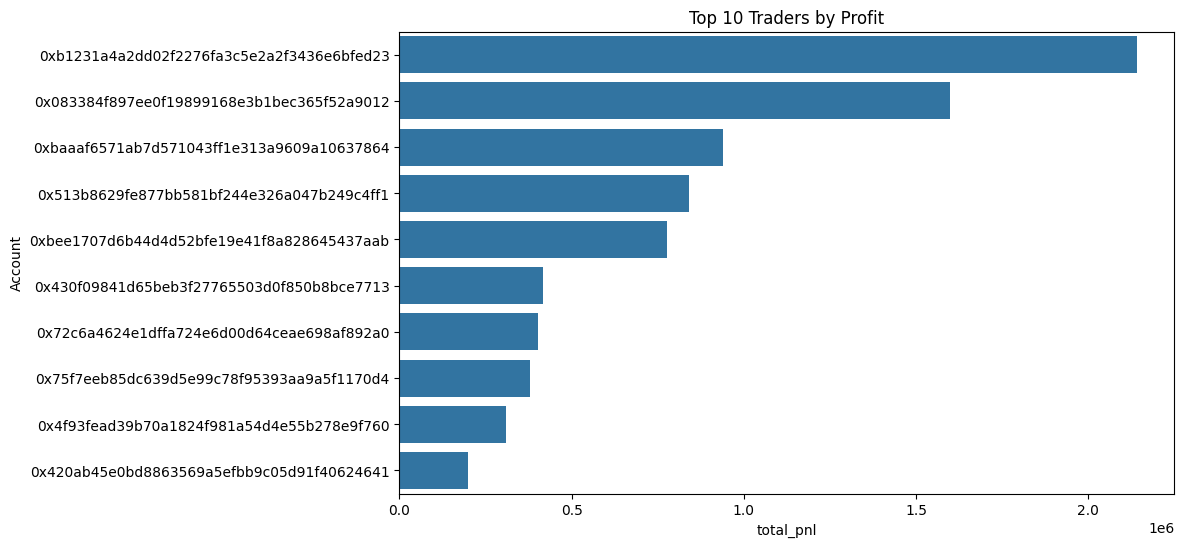

In [33]:
# top 10 traders
top = trader.sort_values("total_pnl", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="total_pnl", y="Account", data=top)
plt.title("Top 10 Traders by Profit")
plt.show()

In [34]:
# drawdown proxy
loss_days = daily[daily["daily_pnl"] < 0]
print("Average Loss Day PnL :", loss_days["daily_pnl"].mean())


Average Loss Day PnL : -9837.99940313158


In [35]:
# final insights
print("Insights")
print("1. Trader profits vary between Fear and Greed market conditions.")
print("2. Trade size changes with sentiment.")
print("3. Frequent traders execute more trades but returns are mixed.")
print("4. Winning traders are fewer but generate larger profits.")


Insights
1. Trader profits vary between Fear and Greed market conditions.
2. Trade size changes with sentiment.
3. Frequent traders execute more trades but returns are mixed.
4. Winning traders are fewer but generate larger profits.


In [36]:
# strategy ideas
print("Strategy Recommendations")
print("1. During Fear days reduce position size and trade carefully.")
print("2. During Greed days use strict stop loss to avoid overconfidence.")
print("3. Frequent traders should limit overtrading.")


Strategy Recommendations
1. During Fear days reduce position size and trade carefully.
2. During Greed days use strict stop loss to avoid overconfidence.
3. Frequent traders should limit overtrading.


In [37]:
 #optional simple prediction
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_data = daily.copy()
model_data["target"] = 0
model_data.loc[model_data["daily_pnl"] > 0, "target"] = 1

x = model_data[["win_rate", "avg_trade_size", "trades"]]
y = model_data["target"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Prediction Accuracy :", accuracy_score(y_test, pred))

Prediction Accuracy : 0.9405940594059405


In [39]:
import os

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

data.to_csv("outputs/cleaned_data.csv", index=False)

In [41]:
daily.to_csv("outputs/daily_summary.csv", index=False)

In [42]:
trader.to_csv("outputs/trader_summary.csv", index=False)